# LANL Earthquake Prediction


## 1.Problem Understanding 

##  Objective
Predict **time_to_failure** using seismic signal "(acoustic_data)".

## Dataset Context
This dataset comes from a laboratory earthquake simulation where:
- Signals are recorded continuously
- Earthquakes occur periodically
- After each earthquake, the signal resets

##  Key Idea
We are NOT predicting earthquakes directly,
but predicting **how close we are to the next failure**

## Challenges
- Extremely noisy signal
- No obvious global pattern
- Patterns exist only in small time windows

<!-- ### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, parental_level_of_education, Lunch and test_preparation_course. -->

### Problem Statement :-
Predict the time remaining before an earthquake using seismic acoustic signal data.  
The goal is to analyze patterns and detect early indicators of failure through exploratory data analysis and modeling.  
This helps in understanding signal behavior and improving earthquake prediction accuracy.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/competitions/LANL-Earthquake-Prediction/data?select=sample_submission.csv
- The data consists of 2 column and  rows are not defined.

### 2 .(i) Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully")


All libraries imported successfully


#### Import CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv("train.csv" , nrows=5000000)


#### Show top 5 records

In [3]:
df.head()

,acoustic_data,time_to_failure
0,12,1.4691
1,6,1.4691
2,8,1.4691
3,5,1.4691
4,8,1.4691


#### Shape of Datasets

In [4]:
df.shape

(5000000, 2)

### 2.(ii) Dataset information
## Dataset Information

The dataset contains continuous seismic signal recordings from laboratory experiments used to simulate earthquake conditions.

- **acoustic_data**: Integer values representing the intensity of seismic vibrations recorded over time.  
- **time_to_failure**: Float values indicating the remaining time (in seconds) before the next earthquake occurs.  

The data is structured as a " time-series ", where each row corresponds to a single measurement at a specific time step. The dataset is large, containing millions of observations, and is typically processed in segments for efficient analysis.

### 2.(iii) Data Checks to perform
- Check for missing or null values in the dataset  
- Verify data types of each column (e.g., int, float)  
- Identify duplicate records (if any)  
- Analyze basic statistics (mean, min, max, std)  
- Detect outliers and extreme spikes in "acoustic_data"  
- Check distribution of target variable "time_to_failure"  
- Validate time-series continuity and ordering  
- Assess memory usage due to large dataset size  

### 3.(i) Check Missing values

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

if missing.sum() == 0:
    print("\n No missing values. Dataset is clean.")
else:
    print("\n Missing values found — need to handle.")

Missing values per column:
acoustic_data      0
time_to_failure    0
dtype: int64

 No missing values. Dataset is clean.


### 3.(ii) Check Duplicates values

In [6]:
duplicates = df.duplicated().sum()
print("Duplicates rows:",duplicates)

if duplicates == 0:
     print("\n No Duplicates values. Dataset is clean.")
else:
    print("\n Duplicates values found — need to handle.")

Duplicates rows: 0

 No Duplicates values. Dataset is clean.


### 3.(iii) Check data types

In [7]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 2 columns):
 #   Column           Dtype  
---  ------           -----  
 0   acoustic_data    int64  
 1   time_to_failure  float64
dtypes: float64(1), int64(1)
memory usage: 76.3 MB


### 3.(iv) Checking the number of unique values of each column

In [8]:
df.nunique()

acoustic_data         2065
time_to_failure    5000000
dtype: int64

### 3.(v) Check statistics of data set

In [9]:
df.describe()

,acoustic_data,time_to_failure
count,5.000000e+06,5.000000e+06
mean,4.589299e+00,8.202601e-01
std,2.488970e+01,3.749370e-01
min,-4.621000e+03,1.710968e-01
25%,2.000000e+00,4.955976e-01
50%,5.000000e+00,8.200984e-01
75%,7.000000e+00,1.144599e+00
max,3.252000e+03,1.469100e+00


### Signal Range Analysis

In [10]:
# Signal Range Analysis (Min AND MAX Range)
print("\nAcoustic Data Range:")
print(f"Min: {df['acoustic_data'].min()}, Max: {df['acoustic_data'].max()}")   

print("\nTime to Failure Range:")
print(f"Min: {df['time_to_failure'].min()}, Max: {df['time_to_failure'].max()}")


Acoustic Data Range:
Min: -4621, Max: 3252

Time to Failure Range:
Min: 0.17109681632, Max: 1.4690999832


### Acoustic data = sound signals produced by vibrations in materials

###  Situation      |      Acoustic Signal
    Stable rock              Low,smooth values
    Stressbuilding           Increasing variation
    Just before earthquake    Sharp spikes

### Defining Threshold value 
There is no universal range for acoustic signals in earthquake data.
The thresholds depend on your dataset distribution
so we hvae to take threhold value according to our datasets

##### Quantile    |   Meaning
    q50(50%)   -    middle value (0.50)
    q75(75%)    -    normal value (0.75)
    q90 (90%)   -     high  value (0.90) - top 10 starts here 
    q99(99%)    -     extreme top 1% (0.99)

In [11]:
# Exact thresholds from YOUR data
q50 = df['acoustic_data'].quantile(0.50)
q75 = df['acoustic_data'].quantile(0.75)
q90 = df['acoustic_data'].quantile(0.90)
q99 = df['acoustic_data'].quantile(0.99)

print(q50, q75, q90, q99)

5.0 7.0 10.0 25.0


In [12]:
def classify_signal(x):
    if abs(x) < q75:
        return "Normal"
    elif abs(x) < q90:
        return "High"
    else:
        return "Extreme"

df['signal_level'] = df['acoustic_data'].apply(classify_signal)

In [13]:
# Rolling standard deviation (volatility)
df['rolling_std'] = df['acoustic_data'].rolling(window=1000).std()

# Signal range (max - min in window)
df['signal_range'] = (
    df['acoustic_data'].rolling(window=1000).max() -
    df['acoustic_data'].rolling(window=1000).min()
)

# Rolling max (peak detection)
df['rolling_max'] = df['acoustic_data'].rolling(window=1000).max()

In [14]:
df['rolling_std']     # volatility
df['signal_range']    # spike strength
df['rolling_max']     # peak detection

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
           ... 
4999995    24.0
4999996    24.0
4999997    24.0
4999998    24.0
4999999    24.0
Name: rolling_max, Length: 5000000, dtype: float64

### Acoustic Signal Classification 

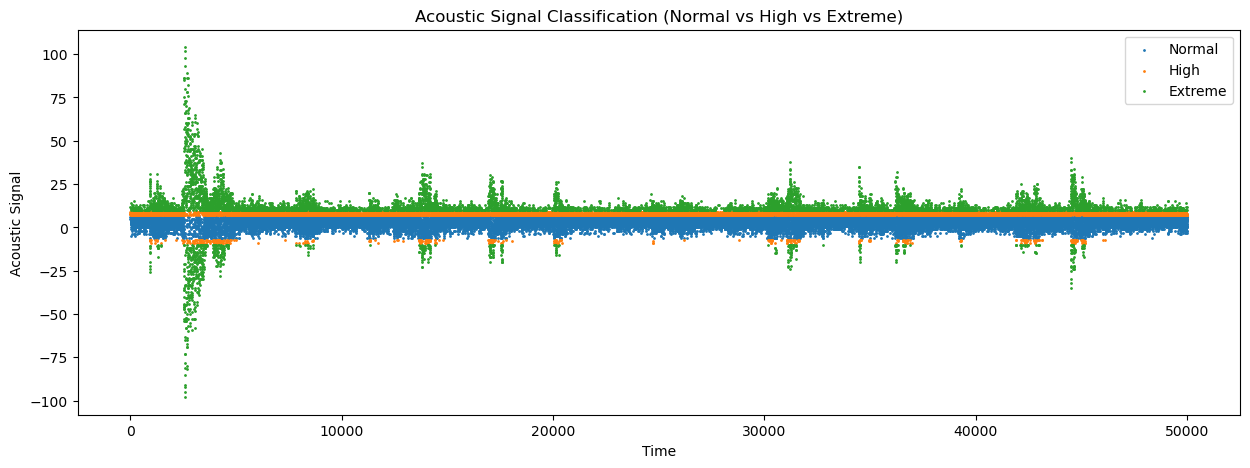

In [15]:

# Take a segment (important due to large data)
segment = df.iloc[0:50000]

# Separate categories
normal = segment[segment['signal_level'] == 'Normal']
high = segment[segment['signal_level'] == 'High']
extreme = segment[segment['signal_level'] == 'Extreme']

plt.figure(figsize=(15,5))

plt.scatter(normal.index, normal['acoustic_data'], s=1, label='Normal')
plt.scatter(high.index, high['acoustic_data'], s=1, label='High')
plt.scatter(extreme.index, extreme['acoustic_data'], s=1, label='Extreme')

plt.title("Acoustic Signal Classification (Normal vs High vs Extreme)")
plt.xlabel("Time")
plt.ylabel("Acoustic Signal")

plt.legend()
plt.show()

### Plot acoustic signal and time_to_failure together


In [16]:
train_sample = df.copy()

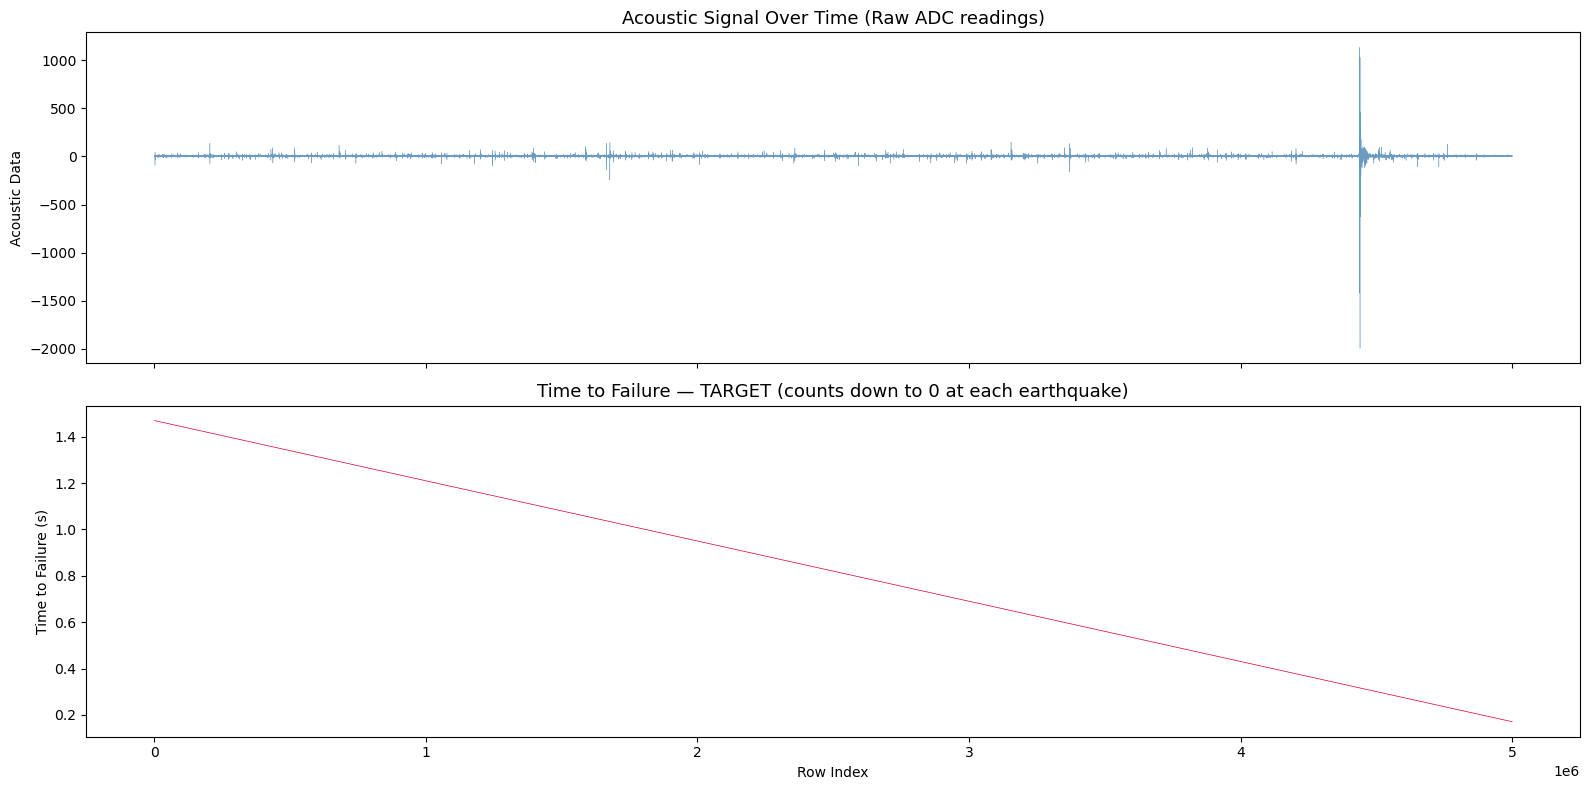

Key Observation:
- time_to_failure linearly DECREASES until it hits 0 (earthquake)
- Then it JUMPS back up (new cycle starts)
- The acoustic signal shows SPIKES near failure points (high amplitude bursts)


In [17]:
# #using df directly
# plot_df = df.iloc[::100]
# x = plot_df.index


# Plot acoustic signal and time_to_failure together
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

plot_df = train_sample.iloc[::100]
x = plot_df.index

axes[0].plot(x, plot_df['acoustic_data'], linewidth=0.3, color='steelblue', alpha=0.8)
axes[0].set_title('Acoustic Signal Over Time (Raw ADC readings)', fontsize=13)
axes[0].set_ylabel('Acoustic Data')

axes[1].plot(x, plot_df['time_to_failure'], linewidth=0.5, color='crimson')
axes[1].set_title('Time to Failure — TARGET (counts down to 0 at each earthquake)', fontsize=13)
axes[1].set_ylabel('Time to Failure (s)')
axes[1].set_xlabel('Row Index')

plt.tight_layout()
plt.show()

print("Key Observation:")
print("- time_to_failure linearly DECREASES until it hits 0 (earthquake)")
print("- Then it JUMPS back up (new cycle starts)")
print("- The acoustic signal shows SPIKES near failure points (high amplitude bursts)")

### Extreme spikes in acoustic signal increases as failure approaches

In [19]:
# q90 = df['acoustic_data'].quantile(0.90)

In [20]:
df['is_extreme'] = abs(df['acoustic_data']) > q90

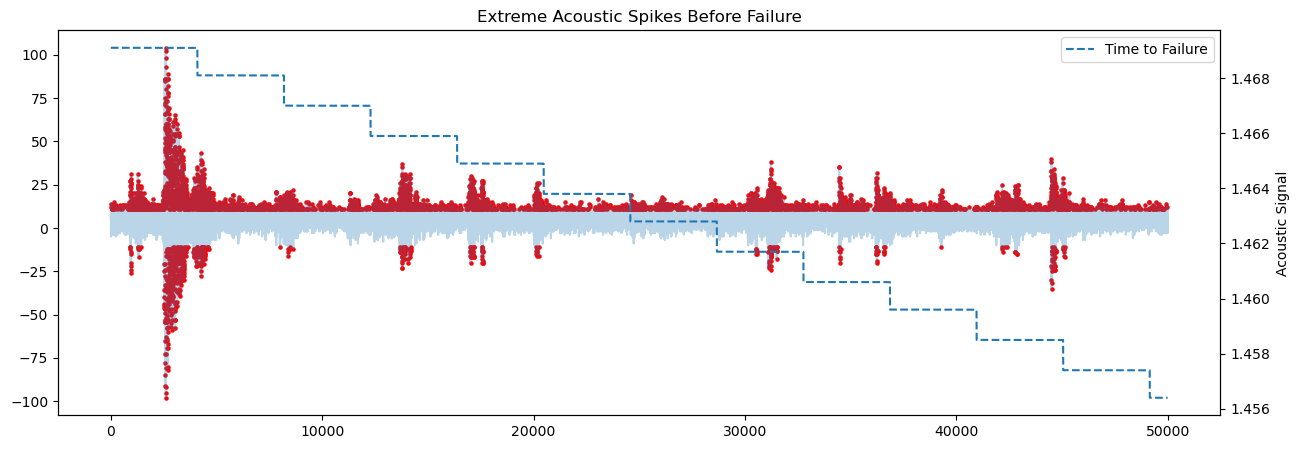

In [21]:
# Take a segment (important)
segment = df.iloc[0:50000]

# Extreme points only
extreme_points = segment[segment['is_extreme']]

plt.figure(figsize=(15,5))

# Plot full signal
plt.plot(segment['acoustic_data'], alpha=0.3, label='Acoustic Signal')

# Highlight extreme spikes
plt.scatter(extreme_points.index, extreme_points['acoustic_data'],
            color='red', s=5, label='Extreme Spikes')

# Plot time_to_failure (secondary axis)
ax2 = plt.gca().twinx()
ax2.plot(segment['time_to_failure'], linestyle='--', label='Time to Failure')

plt.title("Extreme Acoustic Spikes Before Failure")
plt.xlabel("Time")
plt.ylabel("Acoustic Signal")

plt.legend(loc='upper right')
plt.show()

### tarin and use sample for density plot

In [22]:
# Update path accordingly
train = pd.read_csv("train.csv",nrows = 10000000)

print(train.shape)
train.head()

(10000000, 2)


,acoustic_data,time_to_failure
0,12,1.4691
1,6,1.4691
2,8,1.4691
3,5,1.4691
4,8,1.4691


### Side-by-Side Density Plot

In [23]:
sample = train[:25000]

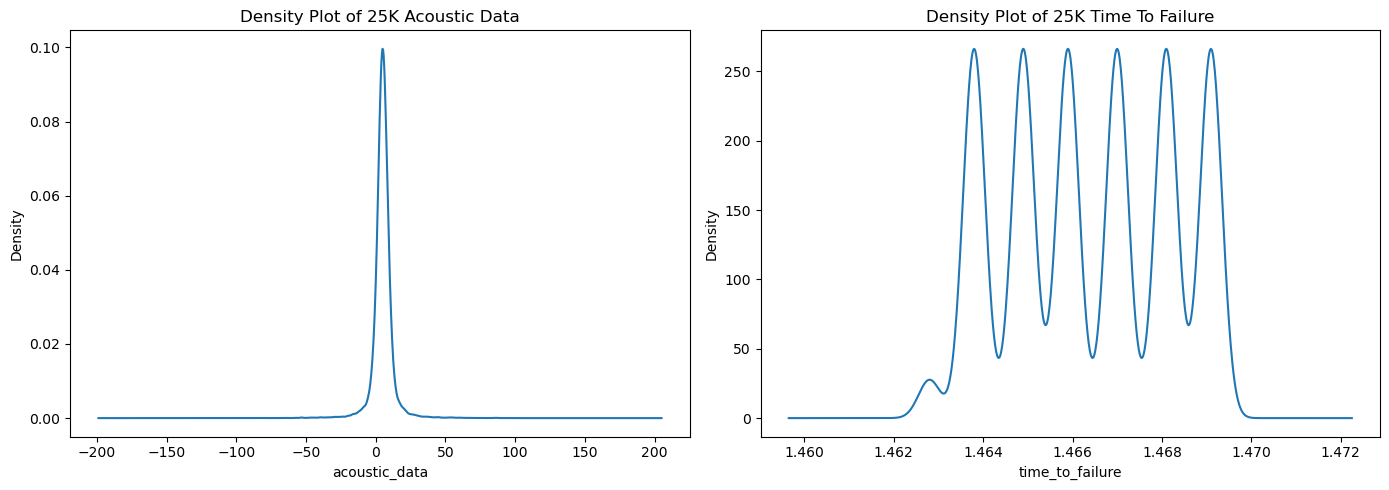

In [24]:
plt.figure(figsize=(14,5)) # figsize=(width,height)
# first plot (left)
plt.subplot(1,2,1) #(1,2,1) - 1 row , 2 column, postion 1 (left)
sample['acoustic_data'].plot(kind='density')
plt.title("Density Plot of 25K Acoustic Data")
plt.xlabel("acoustic_data")
# right plot
plt.subplot(1,2,2) #(1,2,2) - 1 row , 2 column, postion 2 (Right)
sample['time_to_failure'].plot(kind='density')
plt.title("Density Plot of 25K Time To Failure")
plt.xlabel("time_to_failure")

plt.tight_layout()
plt.show()


### Detecting Early Warnings Signal :-
 - Rolling mean smooths the signal
 - Rolling standard deviation highlights sudden fluctuates
 - These are key indicators of potential failure events


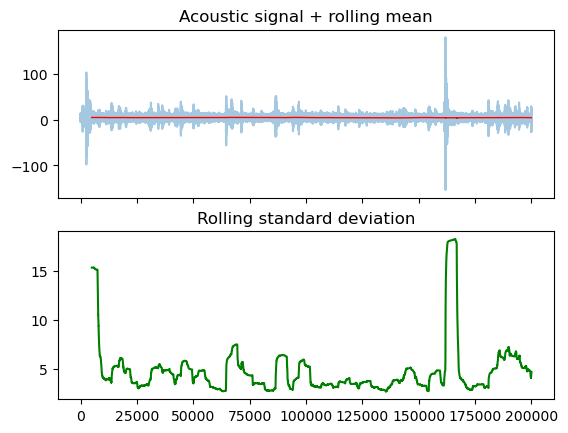

In [25]:
window = 5000  # taking 5000 data points
rolling_mean = train['acoustic_data'].rolling(window).mean()
rolling_std = train['acoustic_data'].rolling(window).std()

fig, ax = plt.subplots(2,1, sharex=True)
ax[0].plot(train['acoustic_data'][:200000], alpha=0.4)
ax[0].plot(rolling_mean[:200000], color='red', linewidth=1)
ax[0].set_title('Acoustic signal + rolling mean')
ax[1].plot(rolling_std[:200000], color='green')
ax[1].set_title('Rolling standard deviation')
plt.show()

### Box Plot Analysis
- To understand data distribution
- To detect outliers and anomalies
- To compare input vs target behavior
- To identify important patterns for feature engineering"""


In [26]:
## WE visualize the distribution of two important varibles:
# - Acoutic Data (input signal)
# - Time to failure(Target variable)


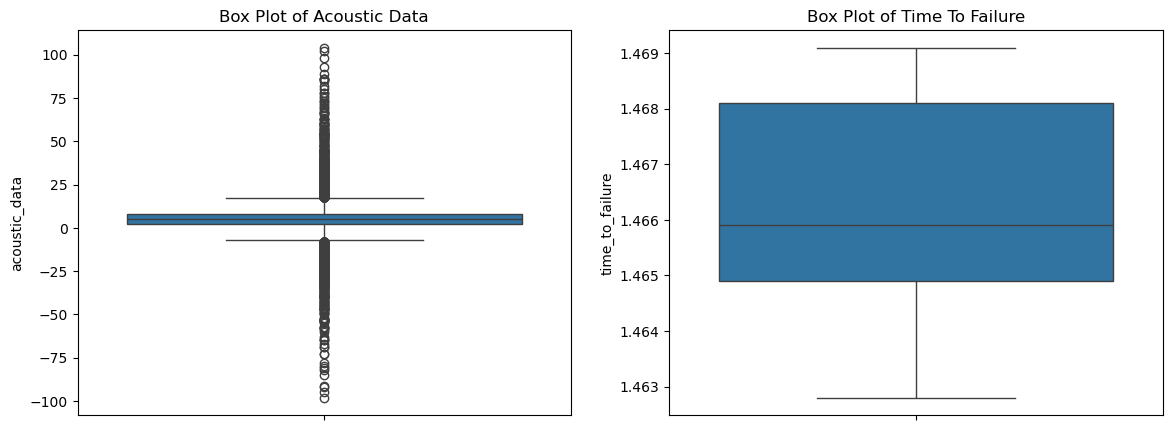

In [27]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.boxplot(data=sample['acoustic_data'])
plt.title("Box Plot of Acoustic Data")

plt.subplot(1,2,2)
# plt.figure(figsize=(14,5))
sns.boxplot(data=sample['time_to_failure'])
plt.title("Box Plot of Time To Failure")
plt.show()

### Conclusion :-
 - Outliers in acoustic data are not errors :- they are valuable signals
 -  spikes should be carefully used, not blindly removed
 - Feature engineering (rolling stats, thresholds) becomes critical

### Segment-Based Feature Engineering :-
 - Segment Size: 150,000 rows
 - Each segment represents a short time window of seismic activity

#### Purpose :- 
Instead of predicting from every single data point,
we predict using summarized behavior of small time windows

In [28]:
segment_size = 150000
segments = int(np.floor(len(df) / segment_size))

means = []
stds = []
targets = []

for i in range(segments):
    seg = df.iloc[i*segment_size:(i+1)*segment_size]
    means.append(seg['acoustic_data'].mean())
    stds.append(seg['acoustic_data'].std())
    targets.append(seg['time_to_failure'].values[-1])

seg_df = pd.DataFrame({
    'mean': means,
    'std': stds,
    'target': targets
})

seg_df.head()

,mean,std,target
0,4.884113,5.101106,1.430797
1,4.725767,6.588824,1.391499
2,4.906393,6.967397,1.353196
3,4.902240,6.922305,1.313798
4,4.908720,7.301110,1.274400


### Insights :-
 - Increasing std (volatility) often indicates instability
 - Changes in mean + std may signal upcoming failure
 - Target decreases approaching earthquake

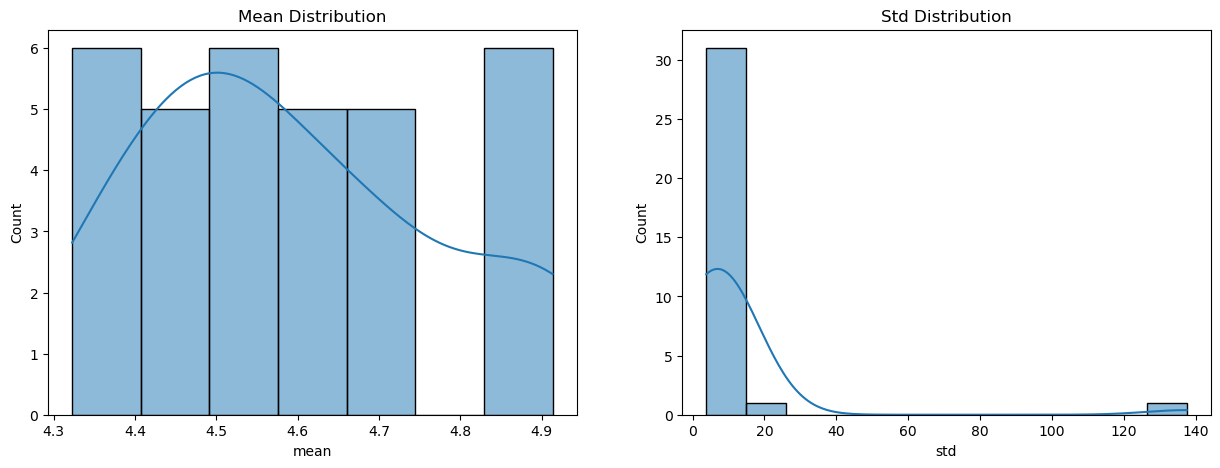

In [29]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.histplot(seg_df['mean'], ax=ax[0], kde=True)
ax[0].set_title("Mean Distribution")

sns.histplot(seg_df['std'], ax=ax[1], kde=True)
ax[1].set_title("Std Distribution")

plt.show()

### Histogram of Acoustic Data

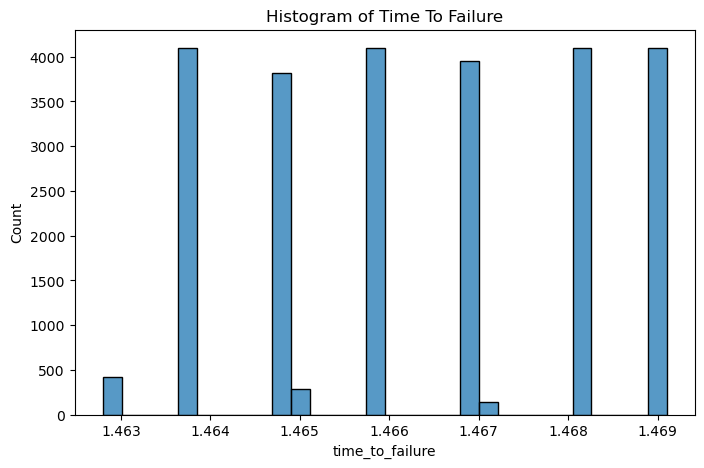

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(sample['time_to_failure'], bins=30)
plt.title("Histogram of Time To Failure")
plt.xlabel("time_to_failure")
plt.ylabel("Count")
plt.show()

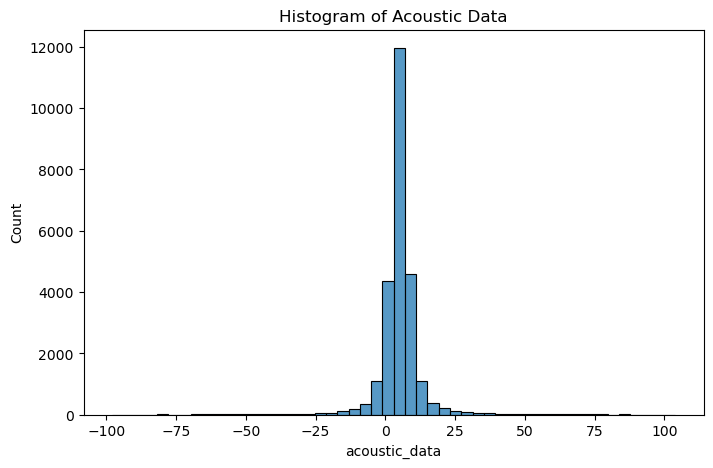

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(sample['acoustic_data'], bins=50)
plt.title("Histogram of Acoustic Data")
plt.xlabel("acoustic_data")
plt.ylabel("Count")
plt.show()

###  Acoustic Data Distribution
 - The acoustic signal is highly concentrated around zero, indicating stable background vibrations. 
 - However, the presence of long tails suggests occasional extreme spikes, which are rare but 
 - important as they may indicate increased stress leading to potential failure events.

### From scipy.stats import  Skew, kurtosis

In [32]:

from scipy.stats import skew, kurtosis

segment_size = 150000
segments = int(np.floor(len(df) / segment_size))

features = []

for i in range(segments):
    seg = df.iloc[i*segment_size:(i+1)*segment_size]
    x = seg['acoustic_data'].values
    
    feature_dict = {
        # Basic stats
        'mean': x.mean(),
        'std': x.std(),
        'max': x.max(),
        'min': x.min(),
        
        # Advanced stats
        'skew': skew(x),
        'kurtosis': kurtosis(x),
        
        # Percentiles (VERY important)
        'q01': np.quantile(x, 0.01),
        'q05': np.quantile(x, 0.05),
        'q95': np.quantile(x, 0.95),
        'q99': np.quantile(x, 0.99),
        
        # Range
        'range': x.max() - x.min(),
        
        # Energy (signal strength)
        'energy': np.sum(x**2),
        
        # Target
        'target': seg['time_to_failure'].values[-1]
    }
    
    features.append(feature_dict)

seg_df = pd.DataFrame(features)
seg_df.head()

,mean,std,max,min,skew,kurtosis,q01,q05,q95,q99,range,energy,target
0,4.884113,5.101089,104,-98,-0.024061,33.661319,-8.0,-2.0,11.0,18.0,202,7481351,1.430797
1,4.725767,6.588802,181,-154,0.390557,98.755185,-11.0,-2.0,12.0,21.0,335,9861777,1.391499
2,4.906393,6.967374,140,-106,0.217388,33.554053,-15.0,-3.0,13.0,26.0,246,10892549,1.353196
3,4.902240,6.922282,197,-199,0.757270,116.544247,-12.0,-2.0,12.0,22.0,396,10792492,1.313798
4,4.908720,7.301086,145,-126,0.064530,52.976099,-15.0,-2.0,12.0,26.0,271,11610208,1.274400


In [33]:
window = 1000

df['rolling_mean'] = df['acoustic_data'].rolling(window).mean()
df['rolling_std'] = df['acoustic_data'].rolling(window).std()
df['rolling_max'] = df['acoustic_data'].rolling(window).max()
df['rolling_min'] = df['acoustic_data'].rolling(window).min()

In [35]:
# threshold = df['acoustic_data'].quantile(0.99) - already define
threshold = df['acoustic_data'].quantile(0.99)
df['spike'] = (df['acoustic_data'].abs() > threshold).astype(int)

In [36]:
spike_count = np.sum(x > threshold)

In [37]:
zero_crossings = np.mean(np.diff(np.sign(x)) != 0)

In [38]:
fft = np.fft.fft(x)
fft_real = np.real(fft)

feature_dict['fft_mean'] = fft_real.mean()
feature_dict['fft_std'] = fft_real.std()

In [39]:
feature_dict['abs_mean'] = np.mean(np.abs(x))
feature_dict['abs_std'] = np.std(np.abs(x))

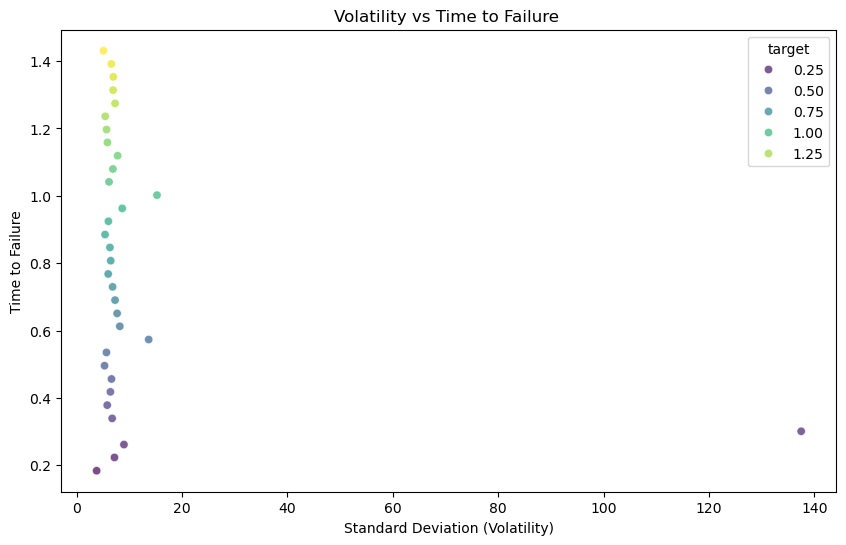

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=seg_df['std'],
    y=seg_df['target'],
    hue=seg_df['target'],   # color by target
    palette='viridis',
    alpha=0.7
)

plt.title("Volatility vs Time to Failure ")
plt.xlabel("Standard Deviation (Volatility)")
plt.ylabel("Time to Failure")

plt.show()

In [41]:
# Volatility combined with target coloring helps reveal hidden patterns not visible in simple scatter plots
# Color adds a third dimension of information
# Helps detect clusters and transitions

### Feature trends across segments
 - Earthquake signals are not constant they show sudden bursts of instability
 - These spikes are not noise
 - They are valuable predictive signals

### Note :- 
 - Volatility is mostly stable but occasionally spikes sharply
 - These spikes may indicate approaching failure

### Feature Distribution

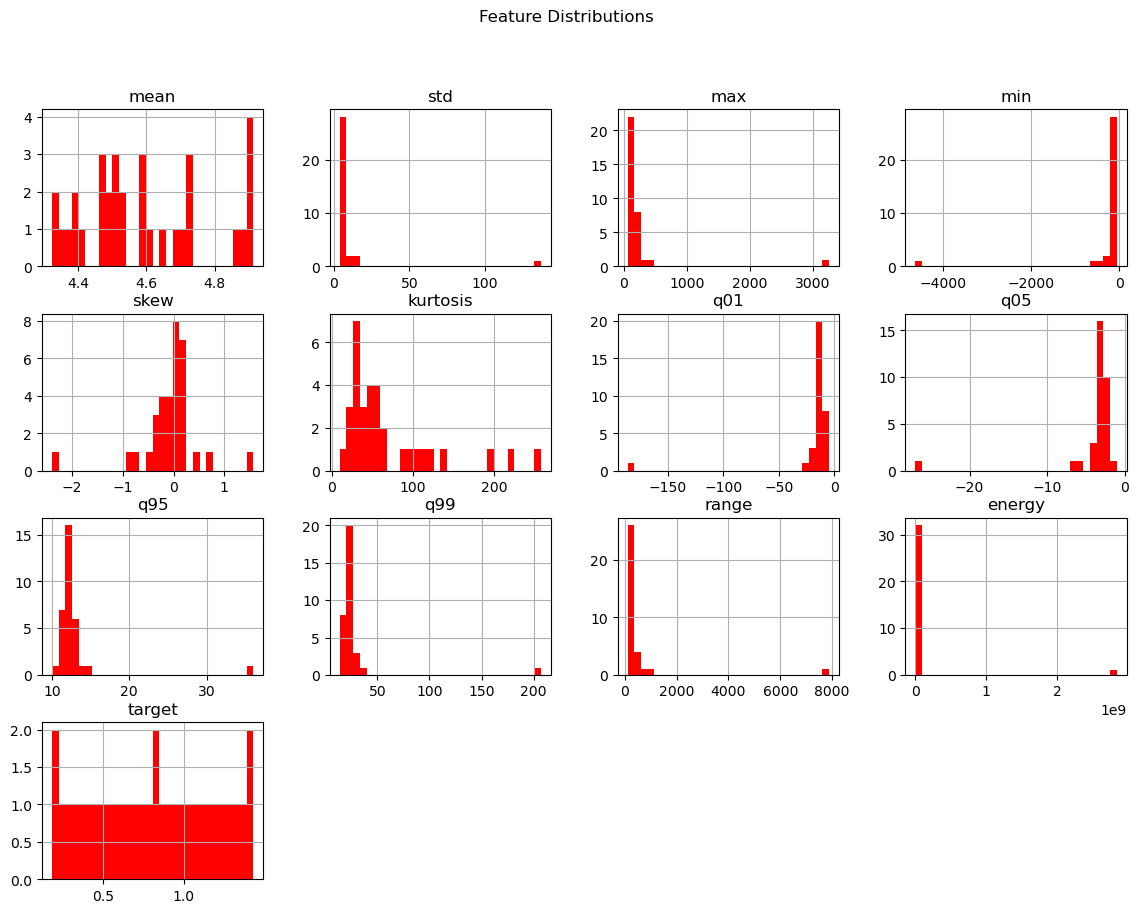

In [119]:
seg_df.hist(figsize=(14,10), bins=30,color = 'red')
plt.suptitle("Feature Distributions")
plt.show()

In [43]:
### Zoomed view of Rolling Feature

In [44]:
# plt.figure(figsize=(14,5))

# plt.plot(df['rolling_std'][:50000], label='Rolling Std')
# plt.plot(df['rolling_mean'][:50000], label='Rolling Mean')

# plt.legend()
# plt.title('Rolling Features (Zoomed View)')

# plt.show()

In [45]:
# # Define threshold (top 1% extreme values)
# threshold = df['acoustic_data'].quantile(0.99)

# plt.figure(figsize=(10,5))

# # Histogram
# plt.hist(df['acoustic_data'], bins=50)

# # Threshold lines
# plt.axvline(threshold, linestyle='--', color='red', label='Extreme Threshold')
# plt.axvline(-threshold, linestyle='--', color='red')

# # Labels
# plt.title("Acoustic Data with Extreme Threshold")
# plt.xlabel("acoustic_data")
# plt.ylabel("Count")

# plt.legend()
# plt.show()

In [46]:
# plt.figure(figsize=(14,5))

# plt.plot(df['rolling_std'][:50000], label='Rolling Std')
# plt.plot(df['rolling_mean'][:50000], label='Rolling Mean')

# plt.legend()
# plt.title('Rolling Features (Zoomed View)')

# plt.show()

<!-- #### You can clearly see that most of the time spikes aree occured near 0 
 -  this shows  **Earthquake signals**
 -  detect Skewness
 -  identify outlier
 -  understand signal behaviour -->